# Four-target SFP: route, analytic-field, and initialization diagnostics

独立诊断 notebook。使用原训练环境，放在 streaming-flow-policy 仓库内，从上到下运行。
读取现有 single / multi 的 final.pt；没有优化器、反向传播或训练循环。

默认：10,000 epochs、seed 0；四个 route-gap 区间各随机选 25 个布局。
另外显示 Layout 11、12、20、13、28、31；额外示例不进入随机样本统计。
四种方法：learned_single、learned_multi、analytic_single、analytic_multi。
每个布局：精确起点一次；初始扰动标准差 0.01 / 0.05 各 20 次。
各方法使用相同扰动。统计所有执行，不挑最好结果。

解析场知道该验证布局的全部专家路线，是诊断参照，不是学出来的策略。
扰动只改变积分初始位置，条件 h 仍使用原布局、原起点；不添加从原起点到扰动点的连线。
这是一项初始化敏感性诊断，不能用来替代固定起点任务的原始成绩。
每次完整运行创建新的诊断目录，不读取以前的轨迹缓存，不修改训练目录。
本文件交付前只做静态语法检查，未执行任何训练或推理。


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import itertools
import json
import os
import platform
import time
import uuid

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import torch
from torch import nn
from IPython.display import display

# 唯一可能需要手动设置的路径。None 时从当前工作目录向上查找。
PROJECT_ROOT_OVERRIDE = None  # e.g. Path(r"D:/projects/streaming-flow-policy")
EXPERIMENT_TAG = "single_vs_multi_05pct_v1"
BUDGET = 10000
TRAINING_SEED = 0

N_PER_GAP_BIN = 25            # None = 使用全部 1,000 个验证布局
LAYOUT_SELECTION_SEED = 2026
PERTURBATION_SEED = 2027
INIT_SIGMAS = [0.0, 0.01, 0.05]
N_PERTURBATIONS = 20
RELATIVE_SLACK = 0.05
VISIT_TOLERANCES = [0.02, 0.05]
RK4_STEPS = 1000
BATCH_SIZE = 100

EXAMPLE_IDS = [11, 12, 20, 13, 28, 31]  # 与原 notebook 相同的零基布局编号
TIME_MARKS = [0.25, 0.5, 0.75]
DETAIL_LAYOUT = 12
PERTURBATION_PLOT_IDS = [12, 20]
PLOT_INIT_SIGMA = 0.05
PLOT_FIRST_N_TRIALS = 8         # 固定展示前八次，不按成败挑图

RUN_ANALYTIC_REFINEMENT = True
MAX_REFINEMENT_PER_GROUP = 4   # 每个解析方法/噪声强度，选失败与接近阈值的案例
REFINEMENT_POSITION_TOL = 0.002

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
METHODS = ["learned_single", "learned_multi", "analytic_single", "analytic_multi"]
GAP_LABELS = ["<1%", "1–<5%", "5–<10%", "≥10%"]
COLORS = dict(learned_single="tab:blue", learned_multi="tab:orange",
              analytic_single="tab:green", analytic_multi="tab:purple")

def find_root():
    if PROJECT_ROOT_OVERRIDE is not None:
        root = Path(PROJECT_ROOT_OVERRIDE).expanduser().resolve()
        if not (root / "experiments/four_boxes_experiments/four_targets/datasets/v1/validation.npz").is_file():
            raise FileNotFoundError(f"Validation data not found under override: {root}")
        return root
    here = Path.cwd().resolve()
    for root in [here, *here.parents]:
        if (root / "experiments/four_boxes_experiments/four_targets/datasets/v1/validation.npz").is_file():
            return root
    raise FileNotFoundError("Run inside the repository, or set PROJECT_ROOT_OVERRIDE.")

assert BUDGET > 0 and TRAINING_SEED >= 0 and N_PERTURBATIONS > 0
assert N_PER_GAP_BIN is None or N_PER_GAP_BIN > 0
assert RK4_STEPS > 0 and BATCH_SIZE > 0
assert len(set(INIT_SIGMAS)) == len(INIT_SIGMAS) and 0.0 in INIT_SIGMAS
assert all(np.isfinite(s) and s >= 0 for s in INIT_SIGMAS)
assert len(set(VISIT_TOLERANCES)) == len(VISIT_TOLERANCES)
assert all(np.isfinite(t) and t > 0 for t in VISIT_TOLERANCES)
assert 0.02 in VISIT_TOLERANCES and 0.05 in VISIT_TOLERANCES
assert PLOT_INIT_SIGMA in INIT_SIGMAS and PLOT_INIT_SIGMA > 0
assert set(PERTURBATION_PLOT_IDS + [DETAIL_LAYOUT]) <= set(EXAMPLE_IDS)
assert all(0 < t < 1 for t in TIME_MARKS)
assert MAX_REFINEMENT_PER_GROUP > 0 and REFINEMENT_POSITION_TOL > 0

PROJECT_ROOT = find_root()
TASK_ROOT = PROJECT_ROOT / "experiments/four_boxes_experiments/four_targets"
VALIDATION_PATH = TASK_ROOT / "datasets/v1/validation.npz"
CHECKPOINT_PATHS = {
    mode: TASK_ROOT / "runs" / EXPERIMENT_TAG / f"budget_{BUDGET}_seed_{TRAINING_SEED}_{mode}" / "final.pt"
    for mode in ["single", "multi"]
}
missing = [str(p) for p in CHECKPOINT_PATHS.values() if not p.is_file()]
if missing:
    raise FileNotFoundError("Missing final checkpoints:\n" + "\n".join(missing))
print("Project:", PROJECT_ROOT)
print("Learned models:", DEVICE, "| analytic fields: NumPy float64 on CPU")
print("No training will be performed.")


Project: /home/matcho/projects/streaming-flow-policy
Learned models: cuda | analytic fields: NumPy float64 on CPU
No training will be performed.


## 1. Load the existing models and validation layouts
网络、输入排序和访问距离计算沿用已检查的训练 notebook。
通过权重配置及验证文件内容哈希核对模型与数据；绝对路径不参与判断。
不需要重新运行数据构建 notebook，也不需要重新运行训练 notebook。


In [2]:
def canonicalize_box_inputs(inputs):
    boxes = inputs[:, 5:].reshape(-1, 4, 2)
    for coordinate in [1, 0]:  # secondary y key, then primary x key
        order = torch.argsort(boxes[:, :, coordinate], dim=1, stable=True)
        boxes = torch.gather(boxes, 1, order.unsqueeze(-1).expand(-1, -1, 2))
    return torch.cat([inputs[:, :5], boxes.reshape(-1, 8)], dim=1)

class CanonicalConditionalVelocityMLP(nn.Module):
    def __init__(self):
        super().__init__()
        layers = []
        width = 13
        for _ in range(4):
            layers.extend([nn.Linear(width, 128), nn.SiLU()])
            width = 128
        layers.append(nn.Linear(width, 2))
        self.network = nn.Sequential(*layers)

    def forward(self, inputs):
        return self.network(2.0 * canonicalize_box_inputs(inputs) - 1.0)

def target_distances(path, targets):
    p0, v = path[:-1], np.diff(path, axis=0)
    w = targets[:,None,:]-p0[None,:,:]
    denom = np.maximum(np.sum(v*v,axis=1), 1e-30)
    u = np.clip(np.sum(w*v[None,:,:],axis=2)/denom[None,:],0,1)
    closest = p0[None,:,:]+u[:,:,None]*v[None,:,:]
    return np.linalg.norm(targets[:,None,:]-closest,axis=2).min(axis=1)

def first_entry_times(path, targets, radius):
    # Solve segment-circle intersections, including endpoints and stationary segments.
    p0, v = path[:-1], np.diff(path,axis=0)
    a = np.sum(v*v,axis=1)
    result = np.full(len(targets), np.inf)
    for j, target in enumerate(targets):
        d = p0-target
        b = 2*np.sum(d*v,axis=1)
        c = np.sum(d*d,axis=1)-radius**2
        discriminant = b*b-4*a*c
        moving = a > 1e-30
        root = np.sqrt(np.maximum(discriminant,0))
        denom = np.where(moving,2*a,1.0)
        enter, leave = (-b-root)/denom, (-b+root)/denom
        hit = moving & (discriminant >= 0) & (leave >= 0) & (enter <= 1)
        u = np.where(c <= 0, 0.0, np.where(hit,np.clip(enter,0,1),np.inf))
        result[j] = np.min(np.arange(len(v))+u)/(len(path)-1)
    return result

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

def atomic_json(value, path):
    path = Path(path)
    temporary = path.with_name(path.name + ".tmp")
    temporary.write_text(json.dumps(value, indent=2, ensure_ascii=False, allow_nan=False), encoding="utf-8")
    os.replace(temporary, path)

def atomic_npz(path, **arrays):
    path = Path(path)
    temporary = path.with_name(path.name + ".tmp")
    with temporary.open("wb") as stream:
        np.savez_compressed(stream, **arrays)
    os.replace(temporary, path)

with np.load(VALIDATION_PATH, allow_pickle=False) as archive:
    validation = {key: archive[key].copy() for key in archive.files}
N_VALIDATION = len(validation["targets"])
if N_VALIDATION != 1000:
    raise ValueError(f"Expected the original 1,000 validation layouts, got {N_VALIDATION}.")
for key, shape in dict(starts=(1000, 2), targets=(1000, 4, 2), conditions=(1000, 10),
                       routes=(1000, 5, 2), knot_tau=(1000, 5), lengths=(1000,)).items():
    if validation[key].shape != shape or not np.isfinite(validation[key]).all():
        raise ValueError(f"Invalid validation field: {key}")
np.testing.assert_array_equal(validation["conditions"], np.concatenate(
    [validation["starts"], validation["targets"].reshape(1000, 8)], axis=1))
np.testing.assert_array_equal(validation["routes"][:, 0], validation["starts"])
assert np.all(np.diff(validation["knot_tau"], axis=1) > 0)
np.testing.assert_allclose(validation["knot_tau"][:, 0], 0, atol=1e-7)
np.testing.assert_allclose(validation["knot_tau"][:, -1], 1, atol=1e-7)
assert all(0 <= i < N_VALIDATION for i in EXAMPLE_IDS)
VALIDATION_SHA256 = sha256_file(VALIDATION_PATH)

models, checkpoint_configs, checkpoint_hashes = {}, {}, {}
for mode, path in CHECKPOINT_PATHS.items():
    checkpoint = torch.load(path, map_location="cpu", weights_only=True)
    cfg = checkpoint["config"]
    expected = dict(num_epochs=BUDGET, training_seed=TRAINING_SEED, sampling=mode,
                    input_preprocessing="sort_targets_by_x_then_y",
                    hidden_dim=128, num_hidden_layers=4, selection="final_epoch")
    differences = {k: (cfg.get(k), v) for k, v in expected.items() if cfg.get(k) != v}
    if checkpoint.get("epoch") != BUDGET or differences:
        raise ValueError(f"{mode}: checkpoint does not match this experiment: {differences}")
    if cfg.get("dataset_sha256", {}).get("validation.npz") != VALIDATION_SHA256:
        raise ValueError(f"{mode}: validation file contents differ from checkpoint metadata.")
    if not np.isclose(cfg.get("relative_slack", -1), RELATIVE_SLACK, rtol=0, atol=1e-12):
        raise ValueError("Use the same near-optimal threshold as the trained models.")
    model = CanonicalConditionalVelocityMLP().to(device=DEVICE, dtype=torch.float64)
    model.load_state_dict(checkpoint["model"], strict=True)
    model.eval()
    models[mode] = model
    checkpoint_configs[mode] = cfg
    checkpoint_hashes[mode] = sha256_file(path)
    del checkpoint

for key in ["sigma_0", "stabilizing_gain", "steps_per_epoch", "batch_size",
            "learning_rate", "weight_decay", "dataset_sha256"]:
    if checkpoint_configs["single"][key] != checkpoint_configs["multi"][key]:
        raise ValueError(f"Paired checkpoints differ in {key}.")
SIGMA_0 = float(checkpoint_configs["multi"]["sigma_0"])
GAIN = float(checkpoint_configs["multi"]["stabilizing_gain"])
assert SIGMA_0 > 0 and GAIN >= 0
print(f"Loaded two final models: {BUDGET} epochs, seed {TRAINING_SEED}")
print(f"Training noise: sigma(t) = {SIGMA_0} * exp(-{GAIN} * t)")


Loaded two final models: 10000 epochs, seed 0
Training noise: sigma(t) = 0.05 * exp(-2.5 * t)


## 2. Enumerate experts and select the diagnostic layouts
原始 single 专家沿用 v1 的路线及 knot_tau。
multi 参照对每个验证布局枚举全部 24 种顺序，并保留长度不超过 1.05 L* 的全部路线。
同长候选不去重；单个布局内各路线先验权重相等，与训练采样规则对应。


In [3]:
starts = validation["starts"].astype(np.float64)
targets = validation["targets"].astype(np.float64)
permutations = np.asarray(list(itertools.permutations(range(4))), dtype=np.int64)
all_routes = np.empty((N_VALIDATION, 24, 5, 2), dtype=np.float64)
for j, order in enumerate(permutations):
    all_routes[:, j] = np.concatenate([starts[:, None], targets[:, order]], axis=1)
segment_lengths = np.linalg.norm(np.diff(all_routes, axis=2), axis=3)
if np.any(segment_lengths <= 0):
    raise ValueError("A route contains a zero-length segment; inspect the source layouts.")
all_lengths = segment_lengths.sum(axis=2)
rankings = np.argsort(all_lengths, axis=1, kind="stable")
optimal_lengths = all_lengths[np.arange(N_VALIDATION), rankings[:, 0]]
second_lengths = all_lengths[np.arange(N_VALIDATION), rankings[:, 1]]
gap_percent = 100 * (second_lengths - optimal_lengths) / optimal_lengths
layout_gap_bins = np.asarray(GAP_LABELS)[np.searchsorted([1., 5., 10.], gap_percent, side="right")]
np.testing.assert_allclose(validation["lengths"], optimal_lengths, rtol=2e-6, atol=1e-7)

candidate_ids, candidate_orders = {}, {}
for i in range(N_VALIDATION):
    ordered = rankings[i]
    keep = all_lengths[i, ordered] <= (1 + RELATIVE_SLACK) * optimal_lengths[i] + 1e-12
    candidate_ids[i] = ordered[keep]
    candidate_orders[i] = {
        tuple(int(x) for x in permutations[j]) for j in candidate_ids[i]
    }

selection_rng = np.random.default_rng(LAYOUT_SELECTION_SEED)
chosen = []
selection_rows = []
for label in GAP_LABELS:
    population = np.flatnonzero(layout_gap_bins == label)
    take = len(population) if N_PER_GAP_BIN is None else min(N_PER_GAP_BIN, len(population))
    picked = selection_rng.choice(population, size=take, replace=False)
    chosen.extend(picked.tolist())
    selection_rows.append(dict(gap_bin=label, full_validation_layouts=len(population),
                               diagnostic_layouts=take))
sample_ids = np.asarray(sorted(chosen), dtype=np.int64)
all_diagnostic_ids = np.asarray(sorted(set(sample_ids.tolist()) | set(EXAMPLE_IDS)), dtype=np.int64)
sample_id_set = set(sample_ids.tolist())
selection_summary = pd.DataFrame(selection_rows)
display(selection_summary)
print("Random diagnostic sample:", len(sample_ids), "layouts")
print("Including illustration-only layouts:", len(all_diagnostic_ids), "layouts")

# Padded route banks. Inactive slots contain a valid duplicate but receive zero probability.
route_banks = {}
for mode in ["single", "multi"]:
    width = 1 if mode == "single" else max(len(v) for v in candidate_ids.values())
    vertices = np.empty((N_VALIDATION, width, 5, 2), dtype=np.float64)
    knots = np.empty((N_VALIDATION, width, 5), dtype=np.float64)
    active = np.zeros((N_VALIDATION, width), dtype=bool)
    for i in range(N_VALIDATION):
        if mode == "single":
            vertices[i, 0] = validation["routes"][i]
            knots[i, 0] = validation["knot_tau"][i]
            active[i, 0] = True
        else:
            indices = candidate_ids[i]
            m = len(indices)
            vertices[i] = all_routes[i, indices[0]]
            expert_knots = np.concatenate(
                [np.zeros((m, 1)), np.cumsum(segment_lengths[i, indices], axis=1)], axis=1)
            expert_knots /= all_lengths[i, indices, None]
            expert_knots[:, -1] = 1.0
            knots[i] = expert_knots[0]
            vertices[i, :m] = all_routes[i, indices]
            knots[i, :m] = expert_knots
            active[i, :m] = True
    assert np.all(np.diff(knots, axis=2) > 0)
    route_banks[mode] = dict(vertices=vertices, knots=knots, active=active)

# Validate that each stored single route visits each target exactly once.
for i in all_diagnostic_ids:
    d = np.linalg.norm(validation["routes"][i, 1:, None] - targets[i, None], axis=-1)
    order = np.argmin(d, axis=1)
    if not np.array_equal(np.sort(order), np.arange(4)) or np.max(d[np.arange(4), order]) > 1e-7:
        raise ValueError(f"Stored single expert has invalid target visits: layout {i}")


,gap_bin,full_validation_layouts,diagnostic_layouts
0,<1%,118,25
1,1–<5%,325,25
2,5–<10%,261,25
3,≥10%,296,25


Random diagnostic sample: 100 layouts
Including illustration-only layouts: 105 layouts


## 3. Shared perturbations and a separate output directory
每个布局先生成一组标准正态向量；两种非零噪声尺度缩放同一组向量。
所有方法共用这些初始位置。sigma=0 只评估一次。
每次运行本单元创建一个新目录，因而不需要跨电脑比较旧 manifest，也不会误用旧缓存。


In [4]:
trial_rows = []
for i in all_diagnostic_ids:
    rng = np.random.default_rng(np.random.SeedSequence([PERTURBATION_SEED, int(i)]))
    epsilon = rng.standard_normal((N_PERTURBATIONS, 2))
    for sigma in INIT_SIGMAS:
        offsets = np.zeros((1, 2)) if sigma == 0 else sigma * epsilon
        for repeat, offset in enumerate(offsets):
            trial_rows.append(dict(
                trial_id=len(trial_rows), layout_index=int(i), initial_sigma=float(sigma),
                repeat_index=repeat, offset_x=float(offset[0]), offset_y=float(offset[1]),
                in_sample=int(i) in sample_id_set, gap_bin=str(layout_gap_bins[i]),
                gap_percent=float(gap_percent[i]), n_candidates=len(candidate_ids[i])))
trials = pd.DataFrame(trial_rows)

stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
OUTPUT_DIR = TASK_ROOT / "diagnostics/multiroute_v1" / (
    f"budget_{BUDGET}_seed_{TRAINING_SEED}_{stamp}_{uuid.uuid4().hex[:6]}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=False)
trials.to_csv(OUTPUT_DIR / "trial_initializations.csv", index=False)
selection_summary.to_csv(OUTPUT_DIR / "layout_selection_summary.csv", index=False)
pd.DataFrame(dict(layout_index=all_diagnostic_ids,
                  in_sample=[int(i) in sample_id_set for i in all_diagnostic_ids],
                  gap_percent=gap_percent[all_diagnostic_ids],
                  gap_bin=layout_gap_bins[all_diagnostic_ids],
                  n_candidates=[len(candidate_ids[i]) for i in all_diagnostic_ids])
             ).to_csv(OUTPUT_DIR / "selected_layouts.csv", index=False)
route_rows = []
for i in all_diagnostic_ids:
    for rank, j in enumerate(candidate_ids[i]):
        route_rows.append(dict(layout_index=int(i), rank=rank + 1,
                               order="→".join(str(x + 1) for x in permutations[j]),
                               length=float(all_lengths[i, j]),
                               excess_percent=float(100 * (all_lengths[i, j] / optimal_lengths[i] - 1))))
pd.DataFrame(route_rows).to_csv(OUTPUT_DIR / "candidate_routes.csv", index=False)

manifest = dict(
    implementation="four_target_diagnostics_v1", budget=BUDGET, training_seed=TRAINING_SEED,
    validation_sha256=VALIDATION_SHA256, checkpoint_sha256=checkpoint_hashes,
    checkpoint_paths={k: p.relative_to(PROJECT_ROOT).as_posix() for k, p in CHECKPOINT_PATHS.items()},
    n_per_gap_bin=N_PER_GAP_BIN, selected_layout_ids=sample_ids.tolist(), example_ids=EXAMPLE_IDS,
    layout_selection_seed=LAYOUT_SELECTION_SEED, perturbation_seed=PERTURBATION_SEED,
    initial_sigmas=INIT_SIGMAS, n_perturbations=N_PERTURBATIONS,
    sigma_0=SIGMA_0, gain=GAIN, relative_slack=RELATIVE_SLACK,
    rk4_steps=RK4_STEPS, batch_size=BATCH_SIZE, tolerances=VISIT_TOLERANCES,
    dtype="float64", reuse_old_rollouts=False, condition_start="original_nominal_start",
    initial_position_clipping=False, origin_to_perturbed_start_segment=False,
    analytic_refinement=RUN_ANALYTIC_REFINEMENT,
    max_refinement_per_group=MAX_REFINEMENT_PER_GROUP,
    refinement_position_tolerance=REFINEMENT_POSITION_TOL)
atomic_json(manifest, OUTPUT_DIR / "manifest.json")
atomic_json(dict(python=platform.python_version(), numpy=np.__version__,
                 torch=str(torch.__version__), device=str(DEVICE),
                 gpu=torch.cuda.get_device_name(DEVICE) if DEVICE.type == "cuda" else None),
            OUTPUT_DIR / "environment.json")
print("Output:", OUTPUT_DIR)
print(f"{len(trials):,} initializations per method; {len(trials) * len(METHODS):,} total rollouts")
print("Only example-layout trajectories are saved; all trials retain numerical metrics.")


Output: /home/matcho/projects/streaming-flow-policy/experiments/four_boxes_experiments/four_targets/diagnostics/multiroute_v1/budget_10000_seed_0_20260925T010535_431530Z_0453b5
4,305 initializations per method; 17,220 total rollouts
Only example-layout trajectories are saved; all trials retain numerical metrics.


## 4. Analytic mixture field and RK4 integration

对候选路线 r，位置分布为 N(xi_r(t), sigma(t)^2 I)，路线先验相等。
因此后验权重为 softmax(-||a-xi_r(t)||^2 / (2 sigma(t)^2))，
混合场为 sum_r w_r [xi'_r(t) - k(a-xi_r(t))]。
这不是将全部路线速度始终等权平均。softmax 使用减去最大值的稳定计算。

single 解析场只使用原始专家；multi 解析场使用全部保留候选。
二者均不执行任何拟合。解析参照与学习模型使用相同的固定步长 RK4 公式。


In [5]:
def expert_values(vertices, knots, tau):
    # vertices: [batch, modes, 5, 2]; knots: [batch, modes, 5]
    segment = np.clip((tau >= knots[..., 1:]).sum(axis=-1), 0, 3)
    b = np.arange(vertices.shape[0])[:, None]
    m = np.arange(vertices.shape[1])[None, :]
    p0, p1 = vertices[b, m, segment], vertices[b, m, segment + 1]
    t0 = knots[b, m, segment]
    duration = knots[b, m, segment + 1] - t0
    derivative = (p1 - p0) / duration[..., None]
    position = p0 + (tau - t0)[..., None] * derivative
    return position, derivative

def make_analytic_field(mode, layout_indices):
    bank = route_banks[mode]
    vertices, knots = bank["vertices"][layout_indices], bank["knots"][layout_indices]
    active = bank["active"][layout_indices]
    def field(actions, tau):
        position, derivative = expert_values(vertices, knots, tau)
        offset = actions[:, None, :] - position
        sigma = SIGMA_0 * np.exp(-GAIN * tau)
        log_weights = -np.sum(offset * offset, axis=-1) / (2 * sigma * sigma)
        log_weights = np.where(active, log_weights, -np.inf)
        log_weights -= np.max(log_weights, axis=1, keepdims=True)
        weights = np.exp(log_weights)
        weights /= np.sum(weights, axis=1, keepdims=True)
        conditional_velocity = derivative - GAIN * offset
        return np.sum(weights[..., None] * conditional_velocity, axis=1)
    return field

def rk4_numpy(field, initial, steps):
    actions = np.asarray(initial, dtype=np.float64).copy()
    paths = np.empty((len(actions), steps + 1, 2), dtype=np.float64)
    paths[:, 0] = actions
    dt = 1.0 / steps
    with np.errstate(over="ignore", invalid="ignore", divide="ignore"):
        for step in range(steps):
            tau = step * dt
            k1 = field(actions, tau)
            k2 = field(actions + 0.5 * dt * k1, tau + 0.5 * dt)
            k3 = field(actions + 0.5 * dt * k2, tau + 0.5 * dt)
            k4 = field(actions + dt * k3, min(tau + dt, 1.0))
            actions += dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
            paths[:, step + 1] = actions
    return paths

@torch.inference_mode()
def rk4_learned(model, layout_indices, initial, steps):
    model.eval()
    conditions = torch.as_tensor(validation["conditions"][layout_indices], device=DEVICE, dtype=torch.float64)
    actions = torch.as_tensor(initial, device=DEVICE, dtype=torch.float64).clone()
    paths = torch.empty((len(actions), steps + 1, 2), device=DEVICE, dtype=torch.float64)
    paths[:, 0] = actions
    def field(a, tau):
        t = torch.full((len(a), 1), tau, device=DEVICE, dtype=torch.float64)
        return model(torch.cat([a, t, conditions], dim=1))
    dt = 1.0 / steps
    for step in range(steps):
        tau = step * dt
        k1 = field(actions, tau)
        k2 = field(actions + 0.5 * dt * k1, tau + 0.5 * dt)
        k3 = field(actions + 0.5 * dt * k2, tau + 0.5 * dt)
        k4 = field(actions + dt * k3, min(tau + dt, 1.0))
        actions = actions + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
        paths[:, step + 1] = actions
    return paths.cpu().numpy()

def integrate(method, batch, steps):
    indices = batch["layout_index"].to_numpy(dtype=np.int64)
    initial = starts[indices] + batch[["offset_x", "offset_y"]].to_numpy(dtype=np.float64)
    kind, mode = method.split("_", 1)
    if kind == "learned":
        return rk4_learned(models[mode], indices, initial, steps)
    if kind == "analytic":
        return rk4_numpy(make_analytic_field(mode, indices), initial, steps)
    raise ValueError(method)

def path_metrics(method, batch, paths):
    records = []
    for record, path in zip(batch.to_dict("records"), paths):
        i = record["layout_index"]
        finite = bool(np.isfinite(path).all())
        distances = target_distances(path, targets[i]) if finite else np.full(4, np.inf)
        length = float(np.linalg.norm(np.diff(path, axis=0), axis=1).sum()) if finite else np.inf
        for tol in VISIT_TOLERANCES:
            visited = int(np.sum(distances <= tol))
            success = finite and visited == 4
            order_text, ambiguous, candidate = "", False, None
            if success:
                hits = first_entry_times(path, targets[i], tol)
                if not np.isfinite(hits).all():
                    ambiguous = True
                else:
                    order = np.argsort(hits, kind="stable")
                    ambiguous = bool(np.any(np.diff(hits[order]) <= 1e-10))
                    order_text = "→".join(str(x + 1) for x in order)
                    if not ambiguous:
                        candidate = tuple(order.tolist()) in candidate_orders[i]
            row = dict(record, method=method, tolerance=float(tol), finite=finite,
                       visited_count=visited, success=success, worst_distance=float(distances.max()),
                       path_length=length, first_visit_order=order_text, order_ambiguous=ambiguous,
                       order_in_nominal_candidate_set=candidate)
            row.update({f"target_{j + 1}_distance": float(d) for j, d in enumerate(distances)})
            records.append(row)
    return pd.DataFrame(records)


## 5. Run inference only
这个单元需要计算时间，但不会训练或修改权重。每种方法都重新积分，不读取旧缓存。
四个方法分别保存指标；示例布局保存完整轨迹，其余布局只保存指标以控制文件体积。
非有限轨迹标记为失败并单独计数，不会静默从统计中剔除。


In [6]:
metric_frames = []
example_paths = {}
for method in METHODS:
    began = time.monotonic()
    frames, kept_ids, kept_paths = [], [], []
    for lo in range(0, len(trials), BATCH_SIZE):
        batch = trials.iloc[lo:lo + BATCH_SIZE]
        paths = integrate(method, batch, RK4_STEPS)
        frames.append(path_metrics(method, batch, paths))
        mask = batch["layout_index"].isin(EXAMPLE_IDS).to_numpy()
        if mask.any():
            kept_ids.extend(batch.loc[mask, "trial_id"].tolist())
            kept_paths.append(paths[mask].copy())
        hi = min(lo + BATCH_SIZE, len(trials))
        elapsed = time.monotonic() - began
        eta = elapsed / hi * (len(trials) - hi)
        print(f"{method}: {hi}/{len(trials)} | elapsed {elapsed/60:.1f} min | ETA {eta/60:.1f} min", flush=True)
    method_metrics = pd.concat(frames, ignore_index=True)
    method_metrics.to_csv(OUTPUT_DIR / f"metrics_{method}.csv", index=False)
    metric_frames.append(method_metrics)
    retained = np.concatenate(kept_paths, axis=0)
    atomic_npz(OUTPUT_DIR / f"example_paths_{method}.npz",
               trial_ids=np.asarray(kept_ids, dtype=np.int64), paths=retained)
    example_paths[method] = {int(key): path for key, path in zip(kept_ids, retained)}
    n_bad = method_metrics.drop_duplicates("trial_id")["finite"].eq(False).sum()
    print(f"{method} finished. Non-finite trajectories: {n_bad}")

metrics = pd.concat(metric_frames, ignore_index=True)
metrics.to_csv(OUTPUT_DIR / "all_trial_metrics.csv", index=False)
print("All inference completed:", OUTPUT_DIR)


learned_single: 100/4305 | elapsed 0.1 min | ETA 2.1 min
learned_single: 200/4305 | elapsed 0.1 min | ETA 1.9 min
learned_single: 300/4305 | elapsed 0.1 min | ETA 1.9 min
learned_single: 400/4305 | elapsed 0.2 min | ETA 1.8 min
learned_single: 500/4305 | elapsed 0.2 min | ETA 1.7 min
learned_single: 600/4305 | elapsed 0.3 min | ETA 1.7 min
learned_single: 700/4305 | elapsed 0.3 min | ETA 1.6 min
learned_single: 800/4305 | elapsed 0.4 min | ETA 1.6 min
learned_single: 900/4305 | elapsed 0.4 min | ETA 1.5 min
learned_single: 1000/4305 | elapsed 0.4 min | ETA 1.5 min
learned_single: 1100/4305 | elapsed 0.5 min | ETA 1.4 min
learned_single: 1200/4305 | elapsed 0.5 min | ETA 1.4 min
learned_single: 1300/4305 | elapsed 0.6 min | ETA 1.3 min
learned_single: 1400/4305 | elapsed 0.6 min | ETA 1.3 min
learned_single: 1500/4305 | elapsed 0.7 min | ETA 1.3 min
learned_single: 1600/4305 | elapsed 0.7 min | ETA 1.2 min
learned_single: 1700/4305 | elapsed 0.8 min | ETA 1.2 min
learned_single: 1800/43

## 6. Summaries and paired comparisons
主表只使用随机抽取的布局；额外挑选的示例不计入。
先对每个布局的扰动重复求成功率，再按 gap 分组平均。
100 个布局按区间等量抽取时，ALL_selected 是该诊断样本的平均，不是原 1,000 布局的总体成功率。
不把同一布局的 20 次扰动当成 20 个独立布局；本 notebook 不生成伪精确置信区间。
顺序分布只在成功且顺序可辨的轨迹上统计，应结合失败率一起看。


,method,initial_sigma,tolerance,gap_bin,n_layouts,n_rollouts,success_percent,mean_visited,mean_worst_distance,nonfinite_percent
0,learned_single,0.00,0.02,ALL_selected,100,100,59.00,3.3300,0.045477,0.0
10,learned_single,0.01,0.02,ALL_selected,100,2000,57.00,3.3025,0.048228,0.0
20,learned_single,0.05,0.02,ALL_selected,100,2000,25.15,2.6120,0.065393,0.0
30,learned_multi,0.00,0.02,ALL_selected,100,100,53.00,3.1700,0.076770,0.0
40,learned_multi,0.01,0.02,ALL_selected,100,2000,48.90,3.1175,0.079392,0.0
50,learned_multi,0.05,0.02,ALL_selected,100,2000,17.85,2.3420,0.126327,0.0
60,analytic_single,0.00,0.02,ALL_selected,100,100,100.00,4.0000,0.000361,0.0
70,analytic_single,0.01,0.02,ALL_selected,100,2000,99.85,3.9985,0.004639,0.0
80,analytic_single,0.05,0.02,ALL_selected,100,2000,50.60,3.3835,0.023018,0.0
90,analytic_multi,0.00,0.02,ALL_selected,100,100,51.00,3.1700,0.076928,0.0


,method,initial_sigma,tolerance,gap_bin,n_layouts,n_rollouts,success_percent,mean_visited,mean_worst_distance,nonfinite_percent
1,learned_single,0.00,0.02,<1%,25,25,16.0,2.360,0.103222,0.0
2,learned_single,0.00,0.02,1–<5%,25,25,52.0,3.360,0.052913,0.0
3,learned_single,0.00,0.02,5–<10%,25,25,80.0,3.760,0.013663,0.0
4,learned_single,0.00,0.02,≥10%,25,25,88.0,3.840,0.012110,0.0
11,learned_single,0.01,0.02,<1%,25,500,14.0,2.388,0.108893,0.0
12,learned_single,0.01,0.02,1–<5%,25,500,47.2,3.268,0.051755,0.0
13,learned_single,0.01,0.02,5–<10%,25,500,80.0,3.740,0.019424,0.0
14,learned_single,0.01,0.02,≥10%,25,500,86.8,3.814,0.012839,0.0
21,learned_single,0.05,0.02,<1%,25,500,8.4,2.008,0.128732,0.0
22,learned_single,0.05,0.02,1–<5%,25,500,20.0,2.514,0.064823,0.0


,reference,candidate,initial_sigma,tolerance,gap_bin,n_layouts,n_rollouts,reference_success_percent,candidate_success_percent,delta_success_pp,rescued_rollouts,regressed_rollouts
0,learned_single,learned_multi,0.00,0.02,ALL_selected,100,100,59.00,53.00,-6.00,7,13
10,learned_single,learned_multi,0.01,0.02,ALL_selected,100,2000,57.00,48.90,-8.10,149,311
20,learned_single,learned_multi,0.05,0.02,ALL_selected,100,2000,25.15,17.85,-7.30,121,267
30,analytic_single,analytic_multi,0.00,0.02,ALL_selected,100,100,100.00,51.00,-49.00,0,49
40,analytic_single,analytic_multi,0.01,0.02,ALL_selected,100,2000,99.85,52.45,-47.40,0,948
50,analytic_single,analytic_multi,0.05,0.02,ALL_selected,100,2000,50.60,28.65,-21.95,26,465
60,analytic_single,learned_single,0.00,0.02,ALL_selected,100,100,100.00,59.00,-41.00,0,41
70,analytic_single,learned_single,0.01,0.02,ALL_selected,100,2000,99.85,57.00,-42.85,0,857
80,analytic_single,learned_single,0.05,0.02,ALL_selected,100,2000,50.60,25.15,-25.45,37,546
90,analytic_multi,learned_multi,0.00,0.02,ALL_selected,100,100,51.00,53.00,2.00,11,9


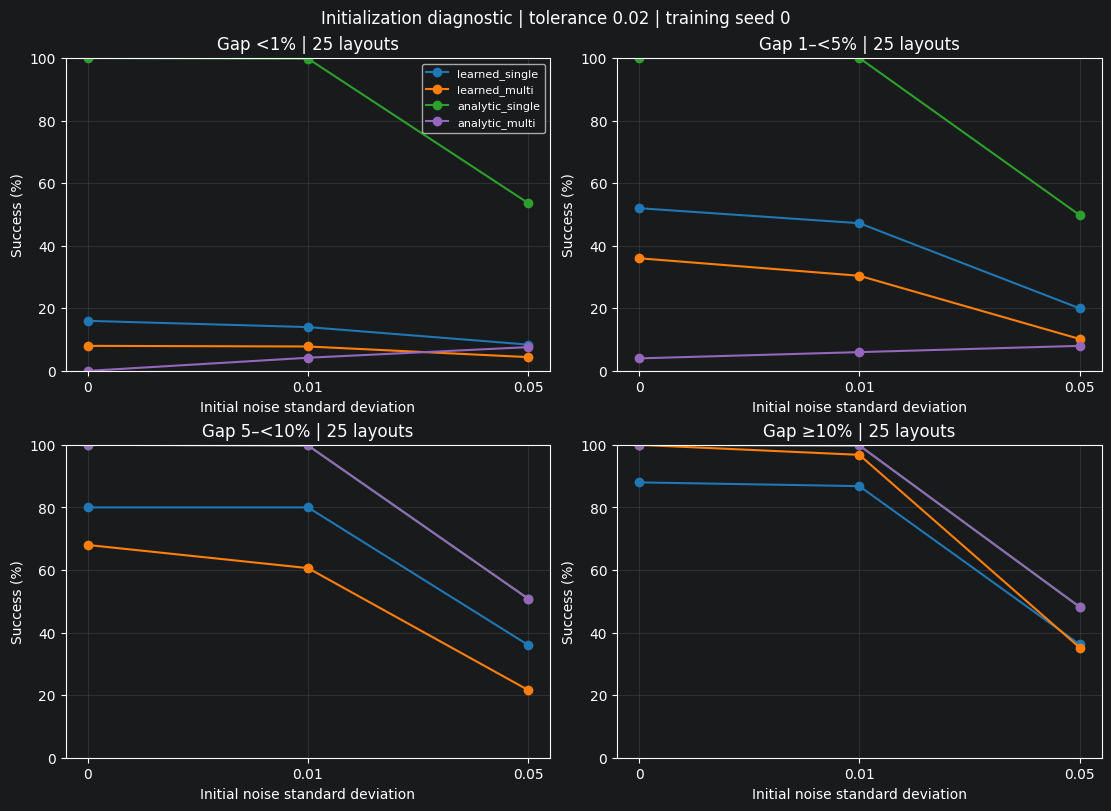

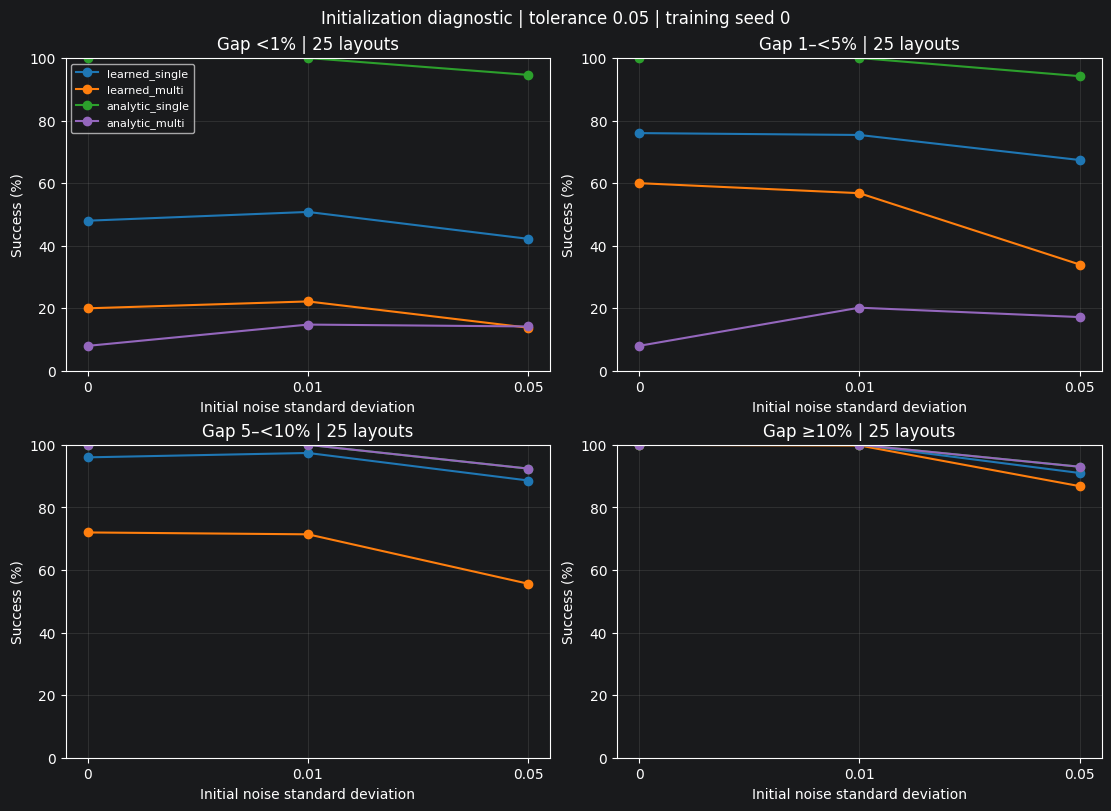

In [8]:
sample_metrics = metrics[metrics["in_sample"]].copy()
layout_summary = sample_metrics.groupby(
    ["method", "layout_index", "gap_bin", "initial_sigma", "tolerance"], sort=False
).agg(n_trials=("trial_id", "size"), success_rate=("success", "mean"),
      mean_visited=("visited_count", "mean"), mean_worst_distance=("worst_distance", "mean"),
      nonfinite_rate=("finite", lambda v: 1 - v.mean())).reset_index()
layout_summary.to_csv(OUTPUT_DIR / "per_layout_summary.csv", index=False)

summary_rows = []
for (method, sigma, tol), group in layout_summary.groupby(["method", "initial_sigma", "tolerance"], sort=False):
    for label in ["ALL_selected", *GAP_LABELS]:
        sub = group if label == "ALL_selected" else group[group["gap_bin"] == label]
        if len(sub):
            summary_rows.append(dict(method=method, initial_sigma=sigma, tolerance=tol, gap_bin=label,
                                     n_layouts=len(sub), n_rollouts=int(sub["n_trials"].sum()),
                                     success_percent=100 * sub["success_rate"].mean(),
                                     mean_visited=sub["mean_visited"].mean(),
                                     mean_worst_distance=sub["mean_worst_distance"].mean(),
                                     nonfinite_percent=100 * sub["nonfinite_rate"].mean()))
summary = pd.DataFrame(summary_rows)
summary.to_csv(OUTPUT_DIR / "diagnostic_summary.csv", index=False)
display(summary[(summary["gap_bin"] == "ALL_selected") & (summary["tolerance"] == 0.02)])
display(summary[(summary["gap_bin"] != "ALL_selected") & (summary["tolerance"] == 0.02)])

pair_rows = []
for reference, candidate in [
    ("learned_single", "learned_multi"), ("analytic_single", "analytic_multi"),
    ("analytic_single", "learned_single"), ("analytic_multi", "learned_multi"),
]:
    left = sample_metrics[sample_metrics["method"] == reference]
    right = sample_metrics[sample_metrics["method"] == candidate]
    pair = left.merge(right, on=["trial_id", "tolerance"], suffixes=("_ref", "_candidate"), validate="one_to_one")
    assert len(pair) == len(left) == len(right)
    for (sigma, tol), g in pair.groupby(["initial_sigma_ref", "tolerance"], sort=False):
        for label in ["ALL_selected", *GAP_LABELS]:
            sub = g if label == "ALL_selected" else g[g["gap_bin_ref"] == label]
            if len(sub):
                s, m = sub["success_ref"], sub["success_candidate"]
                pair_rows.append(dict(reference=reference, candidate=candidate, initial_sigma=sigma,
                                      tolerance=tol, gap_bin=label,
                                      n_layouts=sub["layout_index_ref"].nunique(), n_rollouts=len(sub),
                                      reference_success_percent=100 * s.mean(),
                                      candidate_success_percent=100 * m.mean(),
                                      delta_success_pp=100 * (m.mean() - s.mean()),
                                      rescued_rollouts=int((~s & m).sum()),
                                      regressed_rollouts=int((s & ~m).sum())))
paired_summary = pd.DataFrame(pair_rows)
paired_summary.to_csv(OUTPUT_DIR / "paired_comparisons.csv", index=False)
display(paired_summary[(paired_summary["gap_bin"] == "ALL_selected") &
                       (paired_summary["tolerance"] == 0.02)])

successful_orders = sample_metrics[sample_metrics["success"] & ~sample_metrics["order_ambiguous"]]
order_counts = successful_orders.groupby(
    ["method", "layout_index", "gap_bin", "initial_sigma", "tolerance", "first_visit_order"],
    sort=False).size().rename("count").reset_index()
order_counts.to_csv(OUTPUT_DIR / "successful_visit_orders.csv", index=False)

for tol in VISIT_TOLERANCES:
    fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
    for ax, label in zip(axes.flat, GAP_LABELS):
        for method in METHODS:
            g = summary[(summary["gap_bin"] == label) & (summary["tolerance"] == tol) &
                        (summary["method"] == method)].set_index("initial_sigma").reindex(INIT_SIGMAS)
            ax.plot(range(len(INIT_SIGMAS)), g["success_percent"], "o-", color=COLORS[method], label=method)
        n = int(selection_summary.loc[selection_summary["gap_bin"] == label, "diagnostic_layouts"].iloc[0])
        ax.set(title=f"Gap {label} | {n} layouts", xlabel="Initial noise standard deviation",
               ylabel="Success (%)", ylim=(0, 100))
        ax.set_xticks(range(len(INIT_SIGMAS)), [f"{s:g}" for s in INIT_SIGMAS])
        ax.grid(alpha=0.2)
    axes[0, 0].legend(fontsize=8)
    fig.suptitle(f"Initialization diagnostic | tolerance {tol:g} | training seed {TRAINING_SEED}")
    fig.savefig(OUTPUT_DIR / f"initialization_success_tol_{tol:g}.png", dpi=170)
    plt.show()


## 7. Candidate experts, equal-time markers, and representative trajectories
各图展示同一布局的全部近优专家。圆、方、三角小标记分别对应 TIME_MARKS 中的时刻；
箭头统一长度，只表达方向。目标用黄色大方块，名义起点用绿色星形。
解析曲线是积分得到的，未通过“挑一条专家并照着走”来生成。
x(t)、y(t) 图用于区分空间交叉与同一时刻的接近；额外示例不代表总体发生频率。


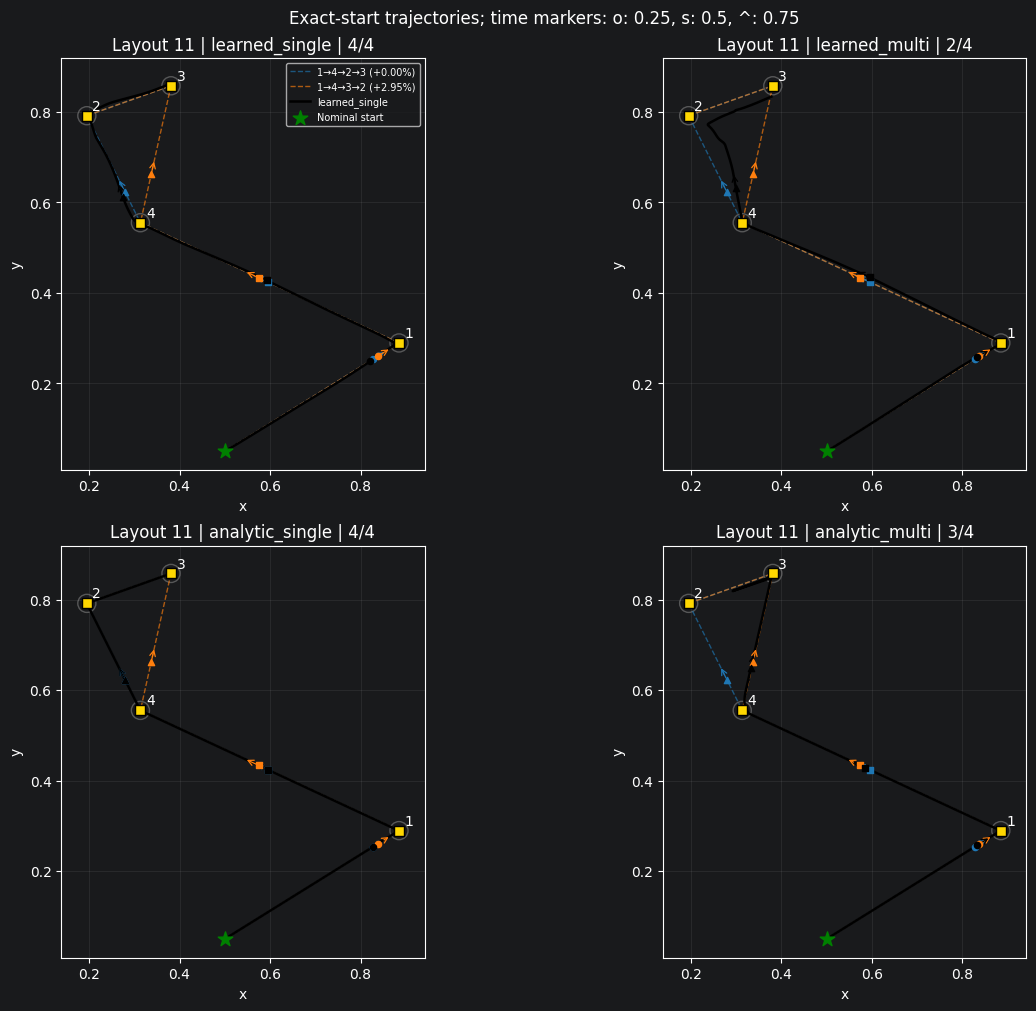

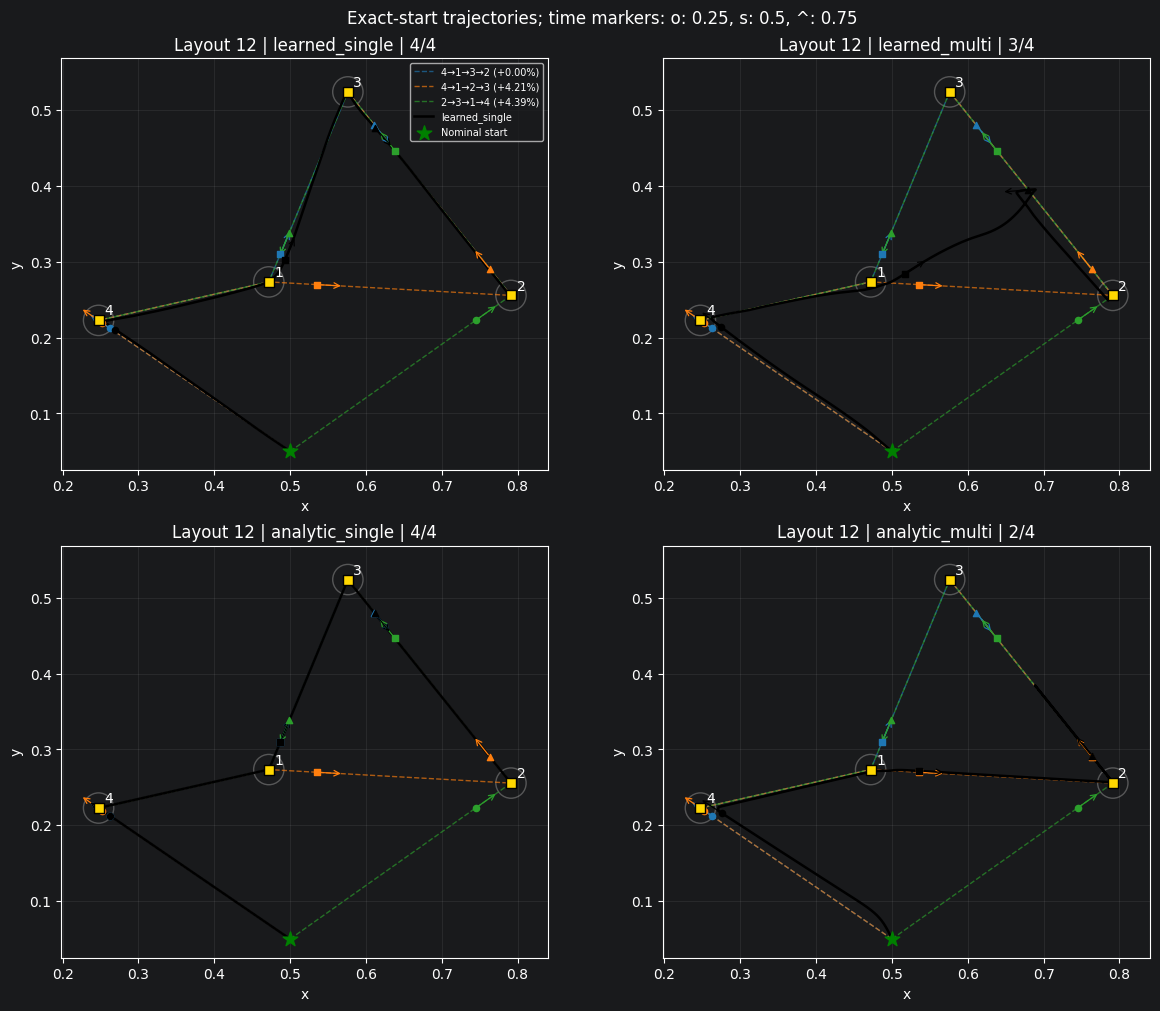

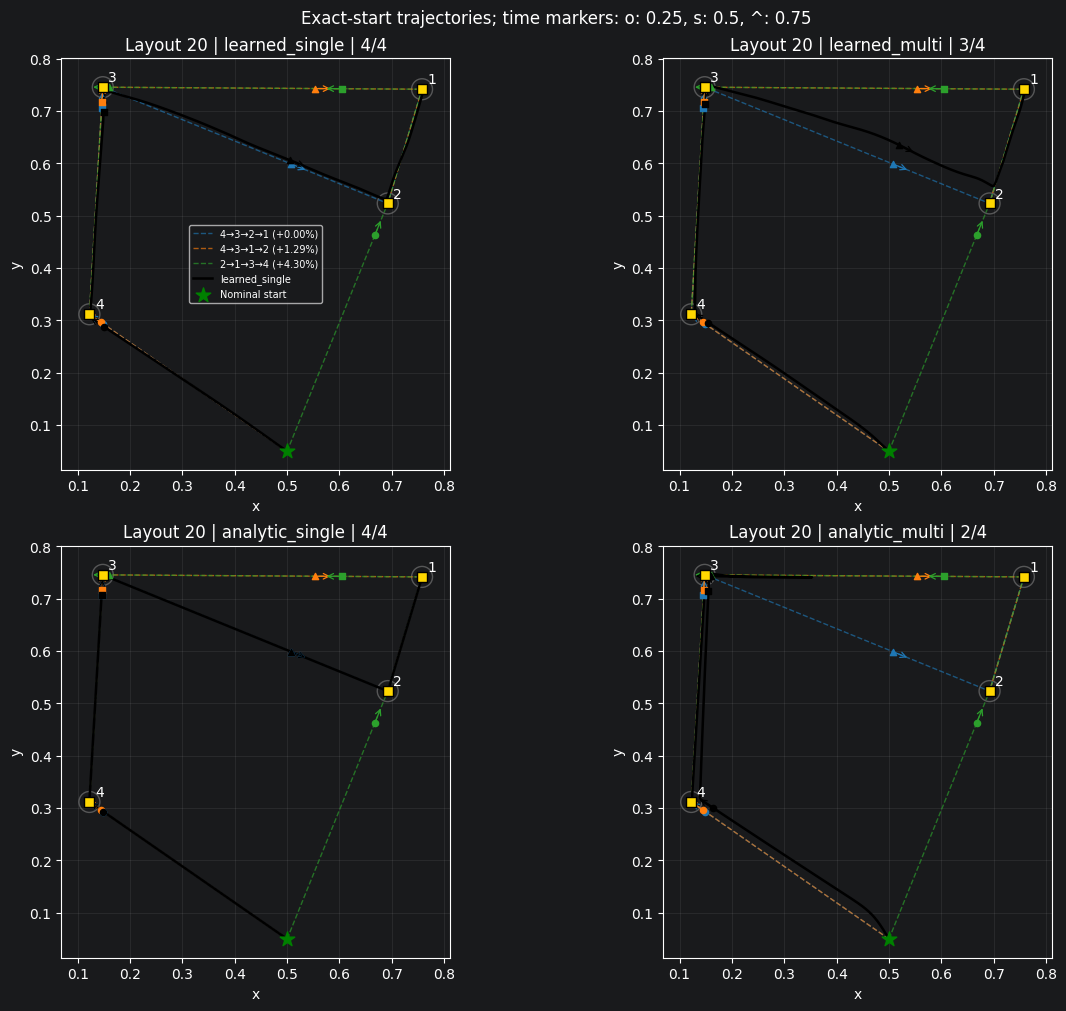

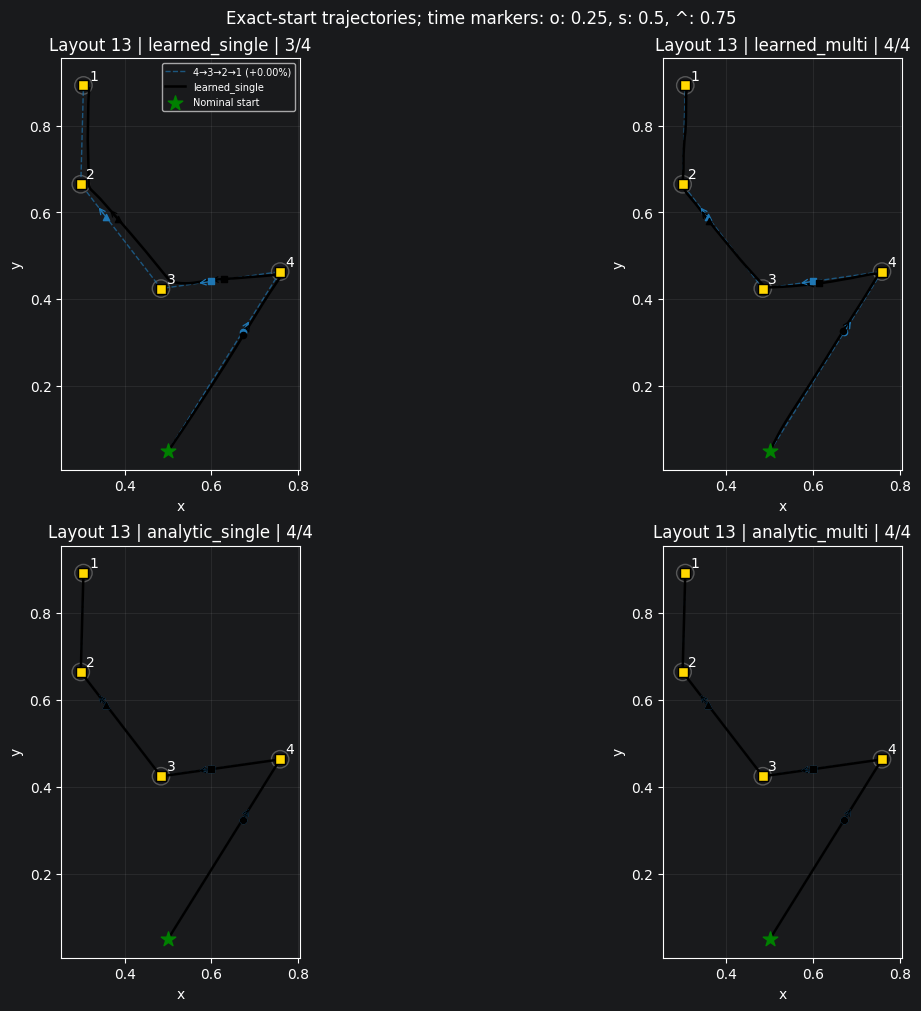

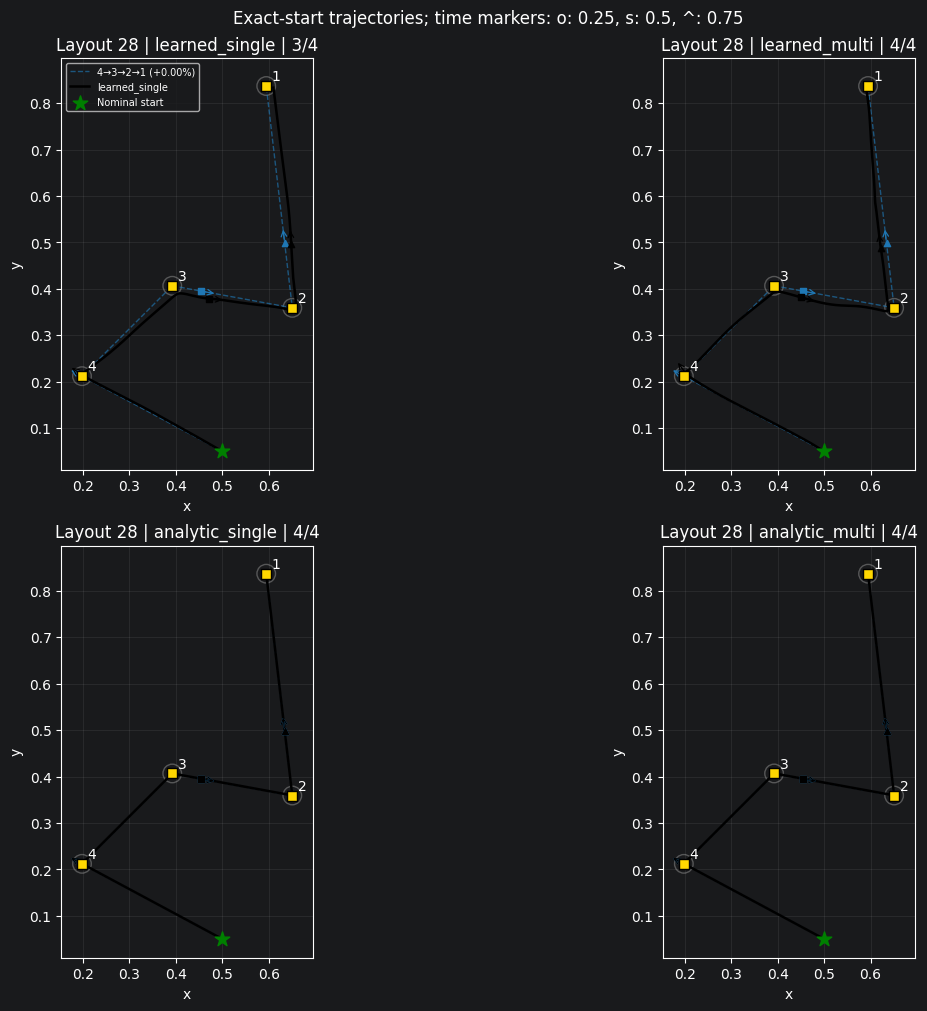

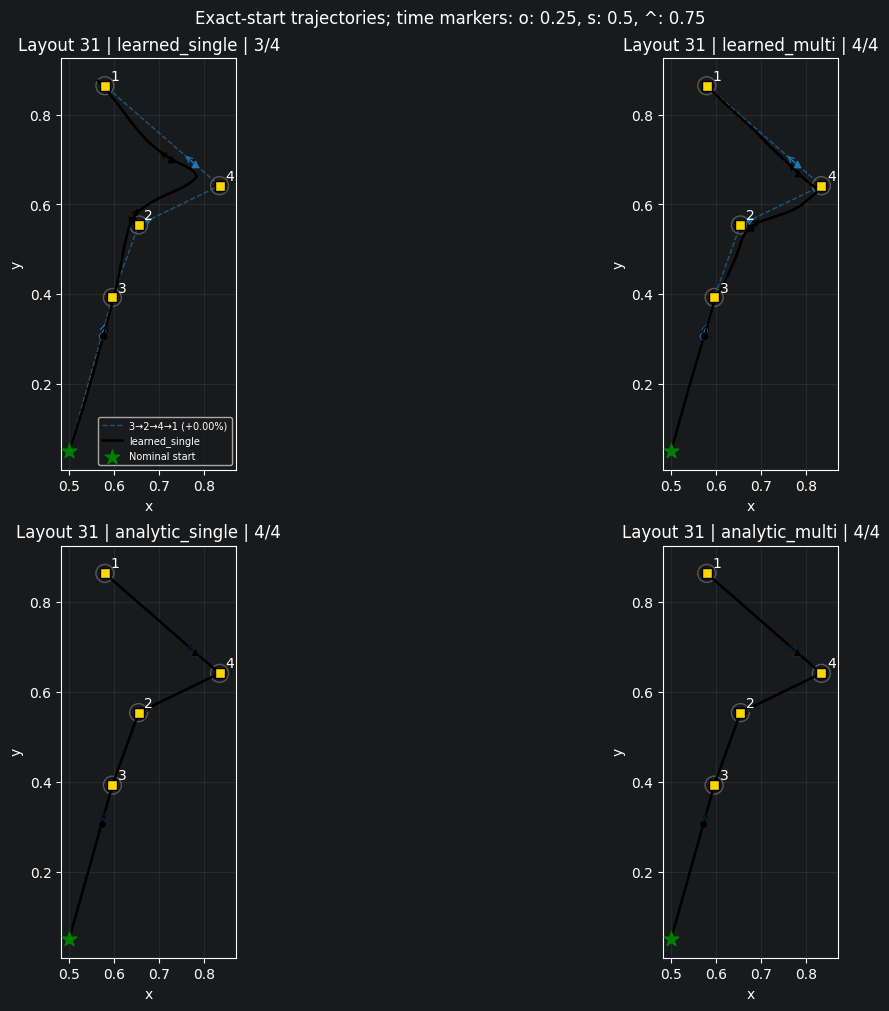

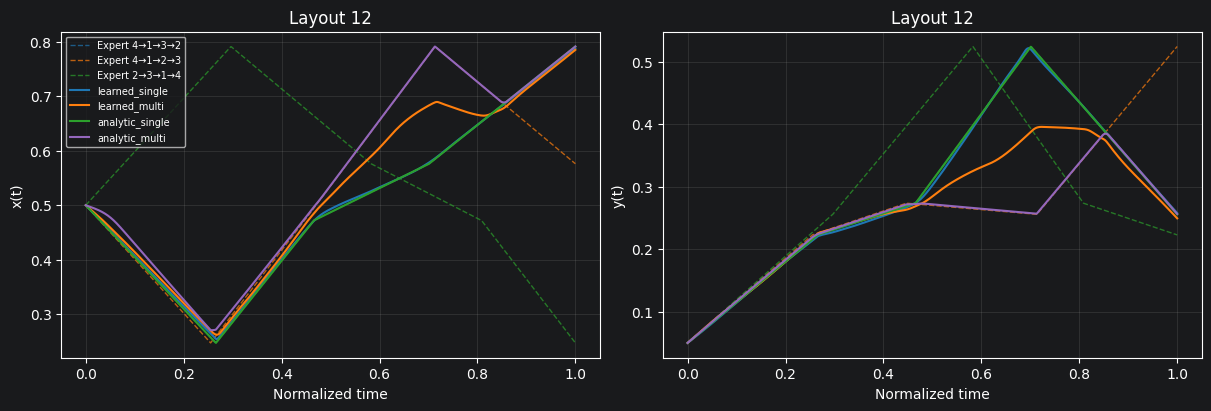

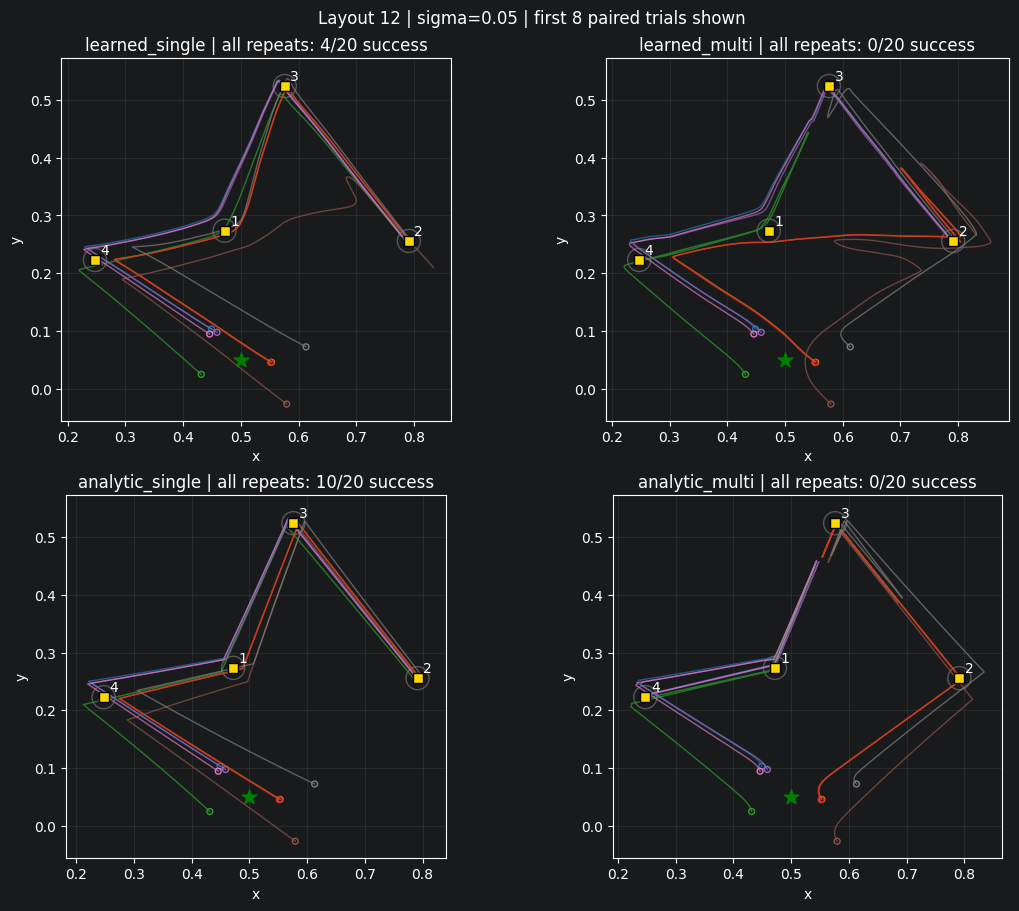

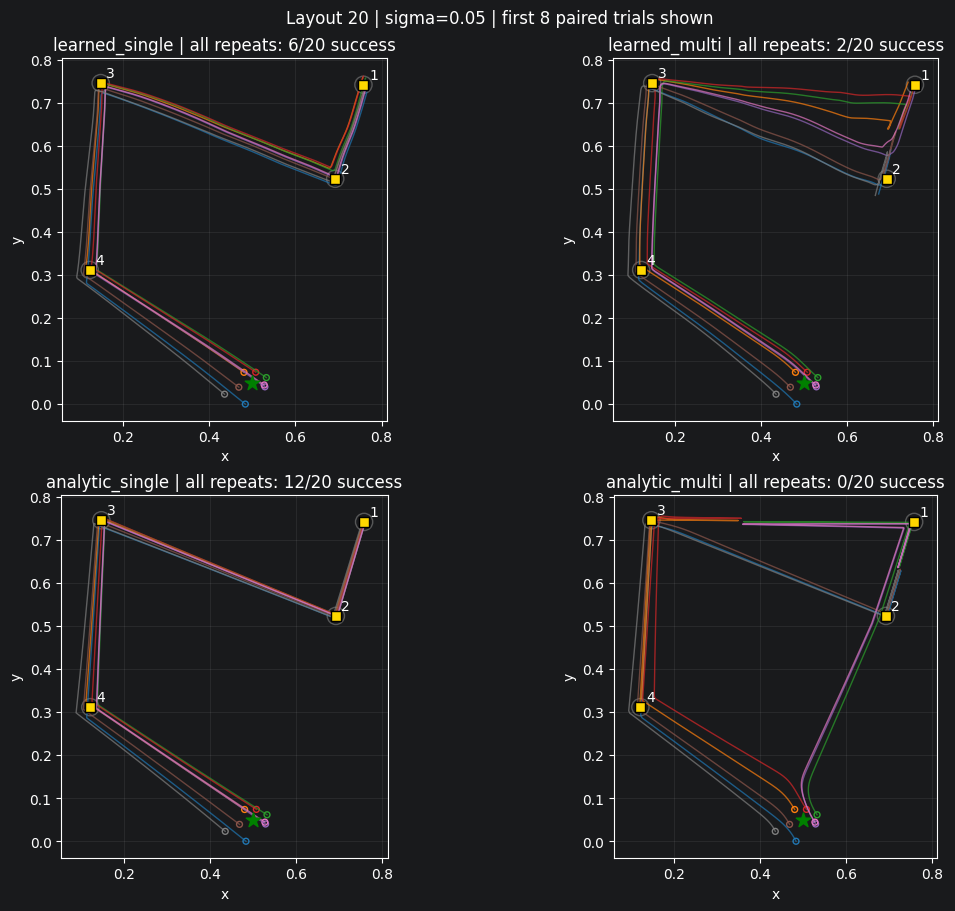

In [9]:
def nominal_trial_id(i):
    row = trials[(trials["layout_index"] == i) & (trials["initial_sigma"] == 0)]
    return int(row.iloc[0]["trial_id"])

def decorate_layout(ax, i, tol=0.02):
    ax.scatter(*starts[i], marker="*", s=120, color="green", zorder=8, label="Nominal start")
    ax.scatter(targets[i, :, 0], targets[i, :, 1], marker="s", s=45,
               color="gold", edgecolors="black", zorder=7)
    for j, target in enumerate(targets[i]):
        ax.add_patch(plt.Circle(target, tol, fill=False, color="gray", alpha=0.6))
        ax.annotate(str(j + 1), target, xytext=(4, 4), textcoords="offset points")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.15)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

def mark_direction(ax, position, direction, marker, color):
    norm = np.linalg.norm(direction)
    ax.scatter(*position, s=20, marker=marker, color=color, zorder=5)
    if np.isfinite(norm) and norm > 1e-12:
        arrow = 0.035 * direction / norm
        ax.annotate("", xy=position + arrow, xytext=position,
                    arrowprops=dict(arrowstyle="->", color=color, lw=0.9))

route_cmap = plt.get_cmap("tab10")
time_markers = ["o", "s", "^", "D", "v", "P"]
for i in EXAMPLE_IDS:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
    key = nominal_trial_id(i)
    for ax, method in zip(axes.flat, METHODS):
        bank = route_banks["multi"]
        for r, j in enumerate(candidate_ids[i]):
            color = route_cmap(r % 10)
            route = all_routes[i, j]
            excess = 100 * (all_lengths[i, j] / optimal_lengths[i] - 1)
            label = "→".join(str(x + 1) for x in permutations[j]) + f" (+{excess:.2f}%)"
            ax.plot(route[:, 0], route[:, 1], "--", lw=1.0, color=color, alpha=0.65, label=label)
            for q, tau in enumerate(TIME_MARKS):
                p, v = expert_values(bank["vertices"][i:i+1, r:r+1],
                                     bank["knots"][i:i+1, r:r+1], tau)
                mark_direction(ax, p[0, 0], v[0, 0], time_markers[q % len(time_markers)], color)
        path = example_paths[method][key]
        if np.isfinite(path).all():
            ax.plot(path[:, 0], path[:, 1], color="black", lw=1.8, label=method)
            for q, tau in enumerate(TIME_MARKS):
                k = int(np.clip(round(tau * RK4_STEPS), 1, RK4_STEPS - 1))
                mark_direction(ax, path[k], path[k+1] - path[k-1], time_markers[q % len(time_markers)], "black")
        else:
            ax.text(0.5, 0.5, "Non-finite trajectory", transform=ax.transAxes, ha="center")
        row = metrics[(metrics["method"] == method) & (metrics["trial_id"] == key) &
                      (metrics["tolerance"] == 0.02)].iloc[0]
        decorate_layout(ax, i)
        ax.set_title(f"Layout {i} | {method} | {int(row['visited_count'])}/4")
    axes[0, 0].legend(fontsize=7)
    fig.suptitle("Exact-start trajectories; time markers: " +
                 ", ".join(f"{time_markers[q % len(time_markers)]}: {t:g}" for q, t in enumerate(TIME_MARKS)))
    fig.savefig(OUTPUT_DIR / f"route_overlay_layout_{i}.png", dpi=160)
    plt.show()

i = DETAIL_LAYOUT
time_grid = np.linspace(0, 1, RK4_STEPS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
bank = route_banks["multi"]
for r, j in enumerate(candidate_ids[i]):
    route = bank["vertices"][i, r]
    knots = bank["knots"][i, r]
    positions = np.column_stack([np.interp(time_grid, knots, route[:, d]) for d in range(2)])
    label = "→".join(str(x + 1) for x in permutations[j])
    for d, ax in enumerate(axes):
        ax.plot(time_grid, positions[:, d], "--", lw=1, alpha=0.7, color=route_cmap(r % 10), label="Expert " + label)
for method in METHODS:
    path = example_paths[method][nominal_trial_id(i)]
    for d, ax in enumerate(axes):
        ax.plot(time_grid, path[:, d], lw=1.5, color=COLORS[method], label=method)
for d, ax in enumerate(axes):
    ax.set(xlabel="Normalized time", ylabel=["x(t)", "y(t)"][d], title=f"Layout {i}")
    ax.grid(alpha=0.2)
axes[0].legend(fontsize=7)
fig.savefig(OUTPUT_DIR / f"position_vs_time_layout_{i}.png", dpi=170)
plt.show()

for i in PERTURBATION_PLOT_IDS:
    examples = trials[(trials["layout_index"] == i) &
                      (trials["initial_sigma"] == PLOT_INIT_SIGMA)].sort_values("repeat_index")
    displayed = examples.head(PLOT_FIRST_N_TRIALS)
    fig, axes = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)
    for ax, method in zip(axes.flat, METHODS):
        for n, key in enumerate(displayed["trial_id"]):
            path = example_paths[method][int(key)]
            if np.isfinite(path).all():
                color = route_cmap(n % 10)
                ax.plot(path[:, 0], path[:, 1], color=color, alpha=0.7, lw=1)
                ax.scatter(*path[0], s=18, facecolors="none", edgecolors=color)
        g = metrics[(metrics["method"] == method) & (metrics["layout_index"] == i) &
                    (metrics["initial_sigma"] == PLOT_INIT_SIGMA) & (metrics["tolerance"] == 0.02)]
        decorate_layout(ax, i)
        ax.set_title(f"{method} | all repeats: {int(g['success'].sum())}/{len(g)} success")
    fig.suptitle(f"Layout {i} | sigma={PLOT_INIT_SIGMA:g} | first {len(displayed)} paired trials shown")
    fig.savefig(OUTPUT_DIR / f"perturbed_paths_layout_{i}.png", dpi=160)
    plt.show()


## 8. Targeted numerical refinement for the analytic references
解析场的专家速度在折线拐点时刻不连续，固定步长积分仍有误差。
每个解析方法/噪声强度，优先选部分最差失败，再选接近访问阈值的案例；
把步数从 1,000 加倍到 2,000。这里只改变积分精度，初始位置与专家保持一致。
结果单独报告，不挑选较好的分辨率混入主表。
success_changed=True 或 position_change 大时，先继续检查积分精度，再解释机制。
这只是选定案例的敏感性检查，不能证明全部解析执行已数值收敛。


In [10]:
if RUN_ANALYTIC_REFINEMENT:
    base = metrics[metrics["method"].str.startswith("analytic_")].drop_duplicates(["method", "trial_id"])
    requests = []
    for (method, sigma), group in base.groupby(["method", "initial_sigma"], sort=False):
        group = group.copy()
        group["threshold_margin"] = np.min(
            np.abs(group["worst_distance"].to_numpy()[:, None] - np.asarray(VISIT_TOLERANCES)[None]), axis=1)
        failed = group[group["worst_distance"] > min(VISIT_TOLERANCES)].sort_values(
            ["worst_distance", "trial_id"], ascending=[False, True])
        selected = failed.head(max(1, MAX_REFINEMENT_PER_GROUP // 2))["trial_id"].tolist()
        remaining = group[~group["trial_id"].isin(selected)].sort_values(["threshold_margin", "trial_id"])
        selected += remaining.head(MAX_REFINEMENT_PER_GROUP - len(selected))["trial_id"].tolist()
        requests.extend((method, int(key)) for key in selected)
    refinement_rows = []
    for method in ["analytic_single", "analytic_multi"]:
        keys = [key for name, key in requests if name == method]
        if not keys:
            continue
        batch = trials.set_index("trial_id", drop=False).loc[keys].reset_index(drop=True)
        coarse = integrate(method, batch, RK4_STEPS)
        fine = integrate(method, batch, 2 * RK4_STEPS)
        coarse_metrics = path_metrics(method, batch, coarse)
        fine_metrics = path_metrics(method, batch, fine)
        atomic_npz(OUTPUT_DIR / f"refinement_paths_{method}.npz",
                   trial_ids=np.asarray(keys), coarse_paths=coarse, fine_paths=fine)
        for j, key in enumerate(keys):
            finite = np.isfinite(coarse[j]).all() and np.isfinite(fine[j]).all()
            change = float(np.linalg.norm(coarse[j] - fine[j, ::2], axis=1).max()) if finite else np.inf
            for tol in VISIT_TOLERANCES:
                a = coarse_metrics[(coarse_metrics["trial_id"] == key) & (coarse_metrics["tolerance"] == tol)].iloc[0]
                b = fine_metrics[(fine_metrics["trial_id"] == key) & (fine_metrics["tolerance"] == tol)].iloc[0]
                refinement_rows.append(dict(
                    method=method, trial_id=key, layout_index=int(a["layout_index"]),
                    initial_sigma=float(a["initial_sigma"]), tolerance=tol,
                    coarse_steps=RK4_STEPS, fine_steps=2*RK4_STEPS,
                    coarse_success=bool(a["success"]), fine_success=bool(b["success"]),
                    success_changed=bool(a["success"] != b["success"]),
                    coarse_worst_distance=float(a["worst_distance"]),
                    fine_worst_distance=float(b["worst_distance"]),
                    max_position_change_at_shared_times=change,
                    position_stable_at_threshold=bool(change <= REFINEMENT_POSITION_TOL)))
    refinement = pd.DataFrame(refinement_rows)
    refinement.to_csv(OUTPUT_DIR / "analytic_step_refinement.csv", index=False)
    display(refinement)
    print("Success-label changes:", int(refinement["success_changed"].sum()))
else:
    print("Analytic refinement skipped. Do not interpret analytic failures as numerically verified.")


,method,trial_id,layout_index,initial_sigma,tolerance,coarse_steps,fine_steps,coarse_success,fine_success,success_changed,coarse_worst_distance,fine_worst_distance,max_position_change_at_shared_times,position_stable_at_threshold
0,analytic_single,1558,366,0.00,0.02,1000,2000,True,True,False,0.000841,0.000409,0.000660,True
1,analytic_single,1558,366,0.00,0.05,1000,2000,True,True,False,0.000841,0.000409,0.000660,True
2,analytic_single,1845,448,0.00,0.02,1000,2000,True,True,False,0.000793,0.000324,0.000710,True
3,analytic_single,1845,448,0.00,0.05,1000,2000,True,True,False,0.000793,0.000324,0.000710,True
4,analytic_single,2501,606,0.00,0.02,1000,2000,True,True,False,0.000663,0.000174,0.000692,True
5,analytic_single,2501,606,0.00,0.05,1000,2000,True,True,False,0.000663,0.000174,0.000692,True
6,analytic_single,2747,690,0.00,0.02,1000,2000,True,True,False,0.000657,0.000161,0.000490,True
7,analytic_single,2747,690,0.00,0.05,1000,2000,True,True,False,0.000657,0.000161,0.000490,True
8,analytic_single,3778,904,0.01,0.02,1000,2000,False,False,False,0.021159,0.021159,0.000290,True
9,analytic_single,3778,904,0.01,0.05,1000,2000,True,True,False,0.021159,0.021159,0.000290,True


Success-label changes: 3


## What to send back
请优先发 diagnostic_summary.csv、paired_comparisons.csv 和 analytic_step_refinement.csv，
或这些表格的截图；附 route_overlay_layout_12.png、position_vs_time_layout_12.png
及初始化成功率图。其他布局的叠加图也可用于对照。

判断顺序：
1. 首先确认解析场失败在加倍步数后是否仍然存在。
2. 比较 learned_multi 与 analytic_multi，区分网络误差与当前场构造的问题。
3. 分别观察两者从精确起点到扰动起点的变化，不把“偶尔成功一次”当作高成功率。
4. 结合全部候选和时间图检查分叉、折返与漏点；候选不属于训练数据泄漏，因为这里只做诊断参照。
初步规律若清楚，再把 N_PER_GAP_BIN 改成 None 使用全部验证布局。
单个训练种子的结果不证明跨种子稳定性；潜变量也不会自动保证完整访问约束。


In [11]:
print("Diagnostics finished. Results:", OUTPUT_DIR)
print("Main tables: diagnostic_summary.csv, paired_comparisons.csv, analytic_step_refinement.csv")
print("Existing training datasets, checkpoints, and original evaluation outputs were not changed.")


Diagnostics finished. Results: /home/matcho/projects/streaming-flow-policy/experiments/four_boxes_experiments/four_targets/diagnostics/multiroute_v1/budget_10000_seed_0_20260925T010535_431530Z_0453b5
Main tables: diagnostic_summary.csv, paired_comparisons.csv, analytic_step_refinement.csv
Existing training datasets, checkpoints, and original evaluation outputs were not changed.
